# Pre-processing degli spettri

Lettura

In [1]:
import h5py
import numpy as np

# Percorso del file generato da EasySpin
file_path = "../data/10k/odmr_easyspin_raw_10000.mat"

# Lettura tramite h5py (standard per MAT-file v7.3)
with h5py.File(file_path, "r") as f:
    # MATLAB salva i dataset trasposti (colonna-prioritaria vs riga-prioritaria)
    # Applichiamo .T per ripristinare la forma corretta: [N_spettri, N_punti]
    spectra_data = np.array(f["spectra_data"]).T
    labels_B = np.array(f["labels_B"]).squeeze()
    labels_D = np.array(f["labels_D"]).squeeze()
    labels_lw = np.array(f["labels_lw"]).squeeze()
    mw_freqs = np.array(f["mw_freqs"]).squeeze()

# Verifica delle dimensioni e dei range fisici
print("--- Controllo Dimensioni ---")
print(f"Spettri grezzi:    {spectra_data.shape} (atteso: [10000, 167])")
print(f"Labels B (mT):     {labels_B.shape}     (atteso: [10000])")
print(f"Labels D (MHz):    {labels_D.shape}     (atteso: [10000])")
print(f"Labels lw (MHz):   {labels_lw.shape}    (atteso: [10000])")
print(f"Asse Frequenze:    {mw_freqs.shape}     (atteso: [167])")

print("\n--- Controllo Valori ---")
print(
    f"Frequenze MW: da {mw_freqs.min():.3f} a {mw_freqs.max():.3f} GHz (o MHz a seconda di EasySpin)"
)
print(f"B field range: da {labels_B.min():.3f} a {labels_B.max():.3f} mT")
print(f"D range:       da {labels_D.min():.1f} a {labels_D.max():.1f} MHz")

--- Controllo Dimensioni ---
Spettri grezzi:    (10000, 167) (atteso: [10000, 167])
Labels B (mT):     (10000,)     (atteso: [10000])
Labels D (MHz):    (10000,)     (atteso: [10000])
Labels lw (MHz):   (10000,)    (atteso: [10000])
Asse Frequenze:    (167,)     (atteso: [167])

--- Controllo Valori ---
Frequenze MW: da 2.750 a 2.950 GHz (o MHz a seconda di EasySpin)
B field range: da 0.002 a 0.237 mT
D range:       da 2842.0 a 2878.0 MHz


In [2]:
# =========================================================================
# CALCOLO TARGET DI REGRESSIONE (GROUND TRUTH)
# =========================================================================

# Costanti fisiche di laboratorio
E_MHz = 10.0  # Anisotropia rombica
gamma_MHz_per_mT = 28.0  # Costante giromagnetica

# Estremi della finestra di sweep (convertiti in MHz se l'asse era in GHz)
if mw_freqs.max() < 10.0:  # se è in GHz
    mw_min_MHz = mw_freqs.min() * 1e3
    mw_max_MHz = mw_freqs.max() * 1e3
else:
    mw_min_MHz = mw_freqs.min()
    mw_max_MHz = mw_freqs.max()

mw_range_MHz = mw_max_MHz - mw_min_MHz

# 1. Calcolo analitico delle frequenze dei due picchi (in MHz)
delta_half_MHz = np.sqrt(E_MHz**2 + (gamma_MHz_per_mT * labels_B) ** 2)
nu_minus_MHz = labels_D - delta_half_MHz
nu_plus_MHz = labels_D + delta_half_MHz

# 2. Coordinate normalizzate in [0, 1]
x1 = (nu_minus_MHz - mw_min_MHz) / mw_range_MHz
x2 = (nu_plus_MHz - mw_min_MHz) / mw_range_MHz

# 3. Parametri aggregati usati nel paper
center_c = (x1 + x2) / 2.0
splitting_s = x2 - x1
width_w = labels_lw / mw_range_MHz

# Matrice dei target: [N_campioni, 5] corrispondenti a [x1, x2, w1, w2, splitting]
# oppure [center, splitting, width] a seconda della formulazione che useremo
targets_dict = {
    "x1": x1,
    "x2": x2,
    "center": center_c,
    "splitting": splitting_s,
    "width": width_w,
}

# Controllo che tutte le risonanze cadano strettamente dentro [0, 1]
print("--- Controllo Bound Normalizzati ---")
print(f"x1 min/max:        [{x1.min():.3f}, {x1.max():.3f}] (deve essere >= 0)")
print(f"x2 min/max:        [{x2.min():.3f}, {x2.max():.3f}] (deve essere <= 1)")
print(f"Centro c min/max:  [{center_c.min():.3f}, {center_c.max():.3f}]")
print(f"Splitting s min/max:[{splitting_s.min():.3f}, {splitting_s.max():.3f}]")

--- Controllo Bound Normalizzati ---
x1 min/max:        [0.400, 0.589] (deve essere >= 0)
x2 min/max:        [0.510, 0.700] (deve essere <= 1)
Centro c min/max:  [0.460, 0.640]
Splitting s min/max:[0.100, 0.120]


In [3]:
print("mw_freqs esatti:")
print("Primo punto:", mw_freqs[0])
print("Ultimo punto:", mw_freqs[-1])
print("Numero punti:", len(mw_freqs))

mw_freqs esatti:
Primo punto: 2.75
Ultimo punto: 2.95
Numero punti: 167


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset, random_split


class ODMRDataset(Dataset):

    def __init__(self, raw_spectra, targets, is_train=True):
        """
        raw_spectra: np.ndarray [N, 167] con picco normalizzato a 1
        targets: np.ndarray [N, K] contenente i valori di riferimento (es.
        center, splitting) 
        is_train: bool, se False fissa il seed per
        rendere riproducibile validation/test
        """
        self.raw_spectra = raw_spectra.astype(np.float32)
        self.targets = targets.astype(np.float32)
        self.is_train = is_train

    def __len__(self):
        return len(self.raw_spectra)

    def __getitem__(self, idx):
        y_ideal = self.raw_spectra[idx]

        # 1. Contrasto ODMR casuale C in [0.012, 0.15]
        contrast = np.random.uniform(0.012, 0.15)
        spectrum_ideal = 1.0 - contrast * y_ideal

        # 2. Shot noise poissoniano:
        # In Yao: N_tot in [180.000, 3.600.000]
        # Noi ri-scaliamo per 167 punti
        n_tot = np.random.uniform(3.0e5, 6.0e6)
        expected_counts = n_tot * (spectrum_ideal / np.sum(spectrum_ideal))
        noisy_counts = np.random.poisson(expected_counts).astype(np.float32)

        # 3. Z-score normalization
        mean_val = np.mean(noisy_counts)
        std_val = np.std(noisy_counts)
        if std_val < 1e-8:
            std_val = 1e-8
        normalized_spectrum = (noisy_counts - mean_val) / std_val

        # Trasformazione in tensori PyTorch (1 canale, 167 campioni)
        x_tensor = torch.from_numpy(normalized_spectrum).unsqueeze(0)
        y_tensor = torch.from_numpy(self.targets[idx])

        return x_tensor, y_tensor


# =========================================================================
# PREPARAZIONE DEI DATALOADER
# =========================================================================

# Costruiamo la matrice dei target primari (in questo caso: [center, splitting])
# Come da articolo, center = c in [0.35, 0.65], splitting = s in [0.167, 0.2]
targets_matrix = np.column_stack([center_c, splitting_s])

# Dataset completo
full_dataset = ODMRDataset(spectra_data, targets_matrix)

# Split 80% train, 10% validation, 10% test
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

generator = torch.Generator().manual_seed(42)
train_subset, val_subset, test_subset = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

# DataLoader
batch_size = 128
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

# Test rapido di estrazione da un batch
sample_x, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_x.shape} (atteso: [{batch_size}, 1, 167])")
print(f"Batch Y shape: {sample_y.shape} (atteso: [{batch_size}, 2])")
print(f"X mean: {sample_x[0].mean():.3f}, X std: {sample_x[0].std():.3f}")

Batch X shape: torch.Size([128, 1, 167]) (atteso: [128, 1, 167])
Batch Y shape: torch.Size([128, 2]) (atteso: [128, 2])
X mean: 0.000, X std: 1.003


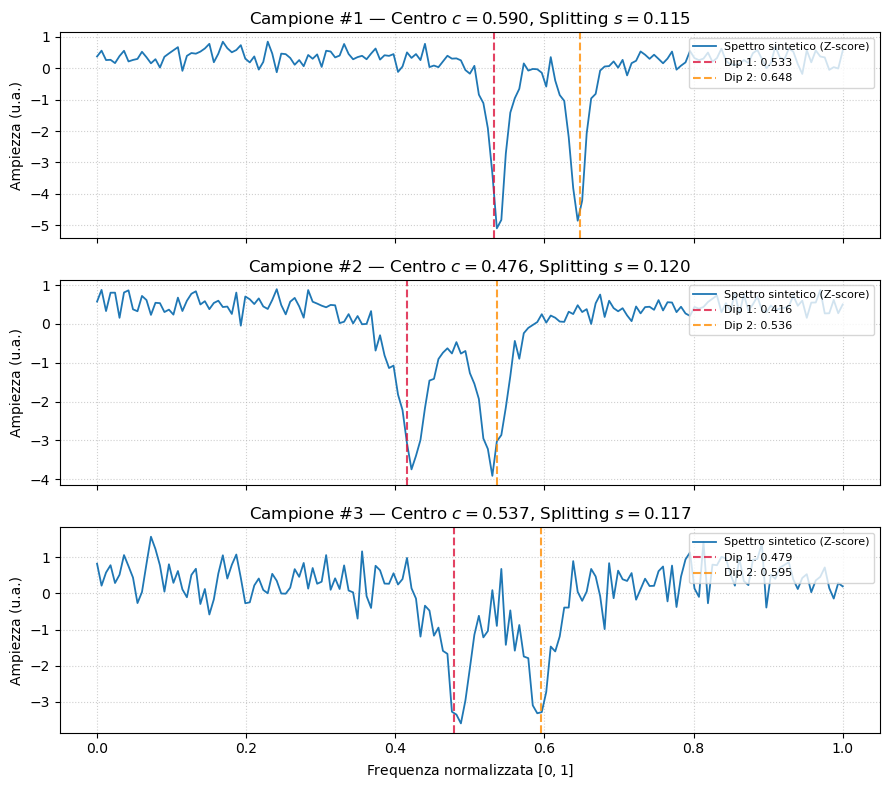

In [5]:
import matplotlib.pyplot as plt

# Estraiamo un batch
inputs, targets = next(iter(train_loader))

# Griglia di frequenze normalizzata [0, 1] e in GHz fisici
freq_norm = np.linspace(0.0, 1.0, 167)
freq_ghz = np.linspace(mw_freqs.min(), mw_freqs.max(), 167)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

for i in range(3):
    ax = axes[i]
    spectrum = inputs[i, 0].numpy()
    c_val, s_val = targets[i].numpy()

    # Coordinate dei due dip calcolate da c e s
    dip1 = c_val - s_val / 2.0
    dip2 = c_val + s_val / 2.0

    # Plot dello spettro Z-score normalizzato
    ax.plot(
        freq_norm,
        spectrum,
        color="#1f77b4",
        lw=1.3,
        label="Spettro sintetico (Z-score)",
    )

    # Linee verticali sui dip ground-truth
    ax.axvline(
        dip1,
        color="crimson",
        linestyle="--",
        alpha=0.8,
        label=f"Dip 1: {dip1:.3f}",
    )
    ax.axvline(
        dip2,
        color="darkorange",
        linestyle="--",
        alpha=0.8,
        label=f"Dip 2: {dip2:.3f}",
    )

    ax.set_ylabel("Ampiezza (u.a.)")
    ax.set_title(
        f"Campione #{i+1} — Centro $c={c_val:.3f}$, Splitting $s={s_val:.3f}$"
    )
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Frequenza normalizzata $[0, 1]$")
plt.tight_layout()
plt.show()


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------------------------------------------------------
# 1. ARCHITETTURA 1D-CNN (Compatibile MPS / Apple Silicon)
# -------------------------------------------------------------------------
class ODMR_CNN1D(nn.Module):
    def __init__(self, input_len=167, num_outputs=2):
        super(ODMR_CNN1D, self).__init__()
        
        # Blocco Convoluzionale 1: 167 -> 83
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Blocco Convoluzionale 2: 83 -> 41
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Blocco Convoluzionale 3: 41 -> 20
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Blocco 4 (Pooling fisso per MPS): 20 -> 10
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Dimensione dopo il pool: 128 canali x 10 punti = 1280
        self.fc1 = nn.Linear(128 * 10, 128)
        self.dropout = nn.Dropout(0.2)
        
        # Output: [mu_c, mu_s, log_var_c, log_var_s] -> 4 uscite
        self.fc_out = nn.Linear(128, num_outputs * 2)

    def forward(self, x):
        # x: [Batch, 1, 167]
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(x)
        
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        out = self.fc_out(x)
        
        mu = out[:, :2]       # [center_c, splitting_s]
        log_var = out[:, 2:]  # [log(sigma_c^2), log(sigma_s^2)]
        
        return mu, log_var

# -------------------------------------------------------------------------
# 2. GAUSSIAN NEGATIVE LOG-LIKELIHOOD LOSS
# -------------------------------------------------------------------------
class GaussianNLLLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(GaussianNLLLoss, self).__init__()
        self.eps = eps

    def forward(self, mu, log_var, target):
        var = torch.exp(log_var) + self.eps
        loss = 0.5 * (((target - mu) ** 2) / var + log_var)
        return torch.mean(loss)

# Verifica del modello su MPS
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = ODMR_CNN1D(input_len=167, num_outputs=2).to(device)
criterion = GaussianNLLLoss()

print(f"Dispositivo di calcolo: {device}")
dummy_x, dummy_y = next(iter(train_loader))
dummy_x, dummy_y = dummy_x.to(device), dummy_y.to(device)

pred_mu, pred_log_var = model(dummy_x)
test_loss = criterion(pred_mu, pred_log_var, dummy_y)

print(f"Output mu shape:      {pred_mu.shape} (atteso: [128, 2])")
print(f"Output log_var shape: {pred_log_var.shape} (atteso: [128, 2])")
print(f"Test Loss iniziale:   {test_loss.item():.4f}")

Dispositivo di calcolo: mps
Output mu shape:      torch.Size([128, 2]) (atteso: [128, 2])
Output log_var shape: torch.Size([128, 2]) (atteso: [128, 2])
Test Loss iniziale:   0.1910
